In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('./fuel_efficiency.csv')
df.head()

,speed_kmh,efficiency_kmpl
0,96.4,19.70
1,52.4,19.59
2,24.9,15.08
3,22.0,14.92
4,117.6,13.30


In [17]:
x = df[['speed_kmh']].to_numpy()
y = df['efficiency_kmpl'].to_numpy()
x.shape, y.shape

((50, 1), (50,))

In [18]:
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.4)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5)
del x_, y_

x_train.shape, y_train.shape, x_cv.shape, y_cv.shape, x_test.shape, y_test.shape

((30, 1), (30,), (10, 1), (10,), (10, 1), (10,))

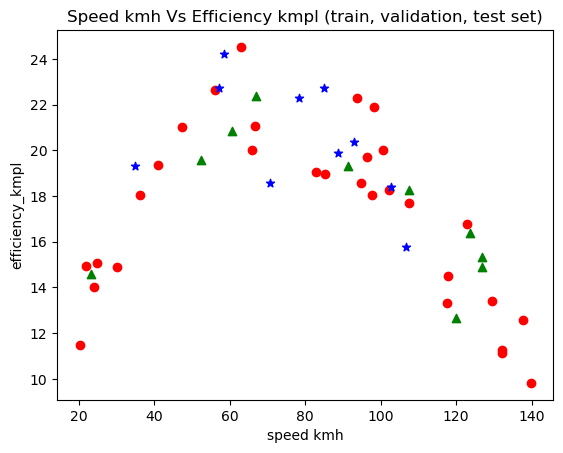

In [21]:
plt.scatter(x_train, y_train, marker ="o", color = "r")
plt.scatter(x_cv, y_cv, marker="*", color="b")
plt.scatter(x_test, y_test, marker="^", color="g")
plt.title("Speed kmh Vs Efficiency kmpl (train, validation, test set)")
plt.xlabel("speed kmh")
plt.ylabel("efficiency_kmpl")
plt.show()

In [25]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)

print(f"x_train: {np.ptp(x_train)}, x_cv: {np.ptp(x_cv)}, x_test: {np.ptp(x_test)}")
print(f"x_train: {np.ptp(x_train_scaled)}, x_cv: {np.ptp(x_cv_scaled)}, x_test: {np.ptp(x_test_scaled)}")

x_train: 119.39999999999999, x_cv: 71.69999999999999, x_test: 103.4
x_train: 3.1323200563856624, x_cv: 1.8809660640104857, x_test: 2.7125786752954566


In [28]:
train_cost = []
cv_cost = []

for i in range(1, 11): # 1 to 10
    poly = PolynomialFeatures(degree = i, include_bias=False)
    # deciding polynomial degrees
    x_train_mapped = poly.fit_transform(x_train)
    x_cv_mapped = poly.transform(x_cv_scaled)

    linear = LinearRegression()
    linear.fit(x_train_mapped, y_train) # training model

    # make predictions
    y_hat_train = linear.predict(x_train_mapped)
    y_hat_cv = linear.predict(x_cv_mapped)

    train_cost.append((mean_squared_error(y_hat_train, y_train) / 2))
    cv_cost.append((mean_squared_error(y_hat_cv, y_cv) / 2))


train_cost, cv_cost

([6.846710322684327,
  1.2485124047332732,
  1.0419325275079803,
  1.0380920635572444,
  1.037152951016324,
  0.9898054779210192,
  0.9799276176418551,
  0.840568033269675,
  0.7750953740881473,
  0.762705921523969],
 [7.450323900313765,
  2.0115212661520294,
  1.4498593152562802,
  1.4350610584139978,
  1.4343498369608292,
  1.5197537599189073,
  1.4612896979661691,
  1.9499693782886063,
  1.7868990329932746,
  1.8294819099435895])

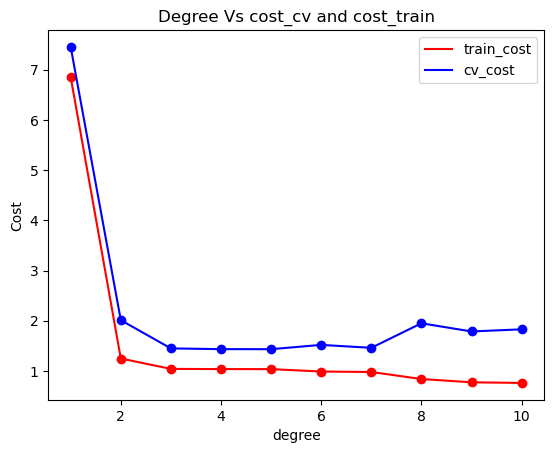

In [30]:
# visuallizing the cost train vs cv
degrees = list(range(1, 11))
plt.scatter(degrees, train_cost, color="r", marker = "o")
plt.plot(degrees, train_cost ,color="r", label="train_cost")
plt.scatter(degrees, cv_cost, color="b", marker = "o")
plt.plot(degrees, cv_cost, color="b", label="cv_cost")
plt.xlabel("degree")
plt.ylabel("Cost")
plt.title("Degree Vs cost_cv and cost_train")
plt.legend()
plt.show()

In [33]:
final_degree = np.argmin(cv_cost)+1
final_degree

np.int64(5)

In [36]:
linear = LinearRegression()
poly = PolynomialFeatures(degree = final_degree, include_bias=False)

final_x_train_mapped = poly.fit_transform(x_train_scaled)
linear.fit(final_x_train_mapped, y_train)
final_y_train = linear.predict(final_x_train_mapped)
final_y_train

array([21.78303453, 12.86291199, 12.41805726, 21.81495271, 17.54845408,
       15.5407339 , 10.93643102, 19.65200437, 21.02153396, 19.42187867,
       12.25394288, 14.15404956, 12.23044415, 21.81587726, 18.48988412,
       15.47647293, 19.22762637, 18.78771852, 14.5406839 , 19.49627911,
       10.46864647, 19.16656588, 21.47727114, 18.35768344, 20.56730556,
       13.24567206, 19.79071815, 14.37734759, 16.52351192, 20.81230651])

In [38]:
x_test_mapped = poly.transform(x_test_scaled)
final_y_test = linear.predict(x_test_mapped)
final_y_test, y_test

(array([17.56706812, 13.4892313 , 21.81364034, 14.21967569, 13.51227225,
        21.17737277, 21.71448485, 20.11986155, 13.88875217, 15.04294311]),
 array([18.25, 14.89, 22.36, 16.38, 15.31, 19.59, 20.83, 19.29, 14.58,
        12.65]))

In [44]:
print(f"R^2:{r2_score(y_test, final_y_test)}")

R^2:0.7625358657500824
